In [1]:
!pip install -q \
  transformers \
  huggingface_hub \
  evaluate \
  spacy

!pip install -U bitsandbytes
!python -m spacy download de_core_news_md

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 16.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 MB 16.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import re
import torch
from peft import PeftModel
from dataclasses import dataclass
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from huggingface_hub import hf_hub_download, login
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from typing import List, Dict
import spacy

In [3]:
login()

In [4]:
@dataclass
class SegmentInfo:
    text: str         # clause/sentence text
    label: str        # "negative" | "neutral" | "positive"
    score: float      # numeric score in [-1, 1]
    length: int       # len(text)

# Class for saving data of one conversation turn
@dataclass
class TurnInfo:
    who: str           # "human" | "bot"
    text: str          # Current sent text
    s_raw: float       # per-turn sentiment in [-1..1] (overall_score)
    s_ema: float       # smoothed per-turn sentiment
    trend: str         # Current trend: "up"|"down"|"flat"
    event: str | None  # "reversal_to_up"/"reversal_to_down"/None
    desired: str       # Desired trend: "up"|"down"|"flat"
    overall_label: str # "negative" | "neutral" | "positive"
    segments: List[SegmentInfo]  # fine-grained sentiment info


In [5]:
# spaCy + regex setup
nlp = spacy.load("de_core_news_md")
SPLIT = re.compile(r'(?<=[.!?])\s+')

LABELS = {"negative", "neutral", "positive"}

CONTRAST_WORDS = {
    "aber", "jedoch", "doch", "sondern", "allerdings",
    "trotzdem", "dennoch", "hingegen", "immerhin",
    "indessen", "indes", "nichtsdestotrotz", "gleichwohl",
    "obwohl", "obgleich", "obschon", "wenngleich",
    "wiewohl", "auch wenn", "selbst wenn",
    "andererseits", "dagegen", "demgegenüber",
    "im gegensatz", "im gegensatz dazu",
    "im gegenteil", "im unterschied dazu",
    "auf der anderen seite", "auf der einen seite",
    "nur", "zwar", "jedoch nur", "wenigstens",
    "mindestens", "zumindest", "bloß",
    "nicht aber", "wenn auch", "obwohl auch", "nur dass",
    "auch wenn", "wenngleich auch",
    "halt aber", "eigentlich aber",
    "trotz alledem", "trotz allem", "trotz der tatsache",
    "trotz der probleme", "ungeachtet dessen",
    "indes", "indessen", "derweil", "zumal",
    "stellte sich jedoch heraus", "hingegen jedoch",
    "gleichwohl", "nichtsdestoweniger", "ungeachtet",
    "dahingegen", "dies hingegen", "dies jedoch"
}

POS_WORDS = {
    "gut", "toll", "super", "klasse", "genial", "top", "positiv",
    "zufrieden", "zufriedenstellend", "beeindruckend", "hervorragend",
    "ausgezeichnet", "wunderbar", "großartig", "fantastisch",
    "angenehm", "komfortabel", "bequem", "funktioniert gut",
    "preiswert", "günstig", "lohnenswert", "empfehlenswert",
    "solide", "verlässlich", "zuverlässig", "stark", "stabil",
    "effizient", "robust", "gut verarbeitet", "hochwertig",
    "leicht bedienbar", "einfach", "übersichtlich",
    "freundlich", "hilfsbereit", "entgegenkommend",
    "pünktlich", "schnell", "rasch",
    "sehr gut", "extrem gut", "überraschend gut",
    "zufriedenstellend", "akzeptabel"
}

NEG_WORDS = {
    "schlecht", "mangelhaft", "furchtbar", "schrecklich",
    "katastrophal", "grauenhaft", "furchtbar", "mies",
    "negativ", "miserabel", "enttäuschend", "enttäuscht",
    "unzufrieden", "ärgerlich", "frustrierend", "problematisch",
    "kaputt", "defekt", "instabil", "unzuverlässig",
    "langsam", "träge", "teuer", "überteuert",
    "billig verarbeitet", "schlecht verarbeitet",
    "kompliziert", "unverständlich", "chaotisch",
    "fehlerhaft", "buggy", "stürzt ab", "hängt",
    "schwach", "unzureichend", "ungenügend",
    "ärgerlich", "frech", "ineffektiv",
    "schlimm", "unbrauchbar", "wertlos"
}

# Convert label to float score
def label_to_score(lbl: str) -> float:
    lbl = lbl.strip().lower()
    if lbl == "positive": return +1.0
    if lbl == "neutral":  return  0.0
    if lbl == "negative": return -1.0
    return 0.0

# This function checks whether a text contains both positive and negative words
def has_mixed_lexicon(text: str) -> bool:
    t = text.lower()
    has_pos = any(w in t for w in POS_WORDS)
    has_neg = any(w in t for w in NEG_WORDS)
    return has_pos and has_neg

# This function splits a text into segments around contrast words such as "aber" or "jedoch"
def spacy_contrast_segments(text: str) -> List[str]:
     # Use the spaCy pipeline to process the text
    doc = nlp(text)
    segments: List[str] = []

    # Iterate over all sentences
    for sent in doc.sents:
        tokens = list(sent)
        cut_indices = []

        for i, tok in enumerate(tokens): # Iterate over all tokens with their index in the sentence
            if tok.text.lower() in CONTRAST_WORDS and tok.pos_ in {"CCONJ", "SCONJ", "ADV"}: # Check if the token is a known contrast word and is a conjunction word or adverb.
                # left_has_verb = any(t.pos_.startswith("V") for t in tokens[:i]) # Check if the part before the contrast word contains at least one verb
                # right_has_verb = any(t.pos_.startswith("V") for t in tokens[i+1:]) # Check if the part after the contrast word contains at least one verb
                # if left_has_verb and right_has_verb:
                    cut_indices.append(i)

        if not cut_indices:
            seg = sent.text.strip()
            if seg:
                segments.append(seg)
            continue

        last = 0
        for idx in cut_indices:
            left_tokens = tokens[last:idx]
            if left_tokens:
                seg = sent[left_tokens[0].i : left_tokens[-1].i + 1].text.strip()
                if seg:
                    segments.append(seg)
            last = idx + 1

        if last < len(tokens):
            right_tokens = tokens[last:]
            seg = sent[right_tokens[0].i : right_tokens[-1].i + 1].text.strip()
            if seg:
                segments.append(seg)

    return [s for s in segments if s]

def spacy_np_vp_split(text: str) -> List[str]:
    doc = nlp(text)
    sent = next(iter(doc.sents), None)
    if sent is None:
        return [text.strip()]

    s_doc = sent.as_doc()
    roots = [t for t in s_doc if t.head == t]
    if not roots:
        return [text.strip()]

    root = roots[0]
    left_span = s_doc[0:root.i]
    right_span = s_doc[root.i:]

    left = left_span.text.strip()
    right = right_span.text.strip()

    if len(left.split()) >= 2 and len(right.split()) >= 2:
        return [left, right]

    return [text.strip()]

In [6]:
# Smoothing
class EMA:
    def __init__(self, alpha=0.35):
        self.a, self.v = alpha, None

    def reset(self):
        self.v = None

    def update(self, x: float) -> float:
        self.v = x if self.v is None else (self.a * x + (1 - self.a) * self.v)
        return self.v

# Trend reversal detection
class Trend:
    def __init__(self, up_thr=+0.06, down_thr=-0.06, sustain=2):
        self.up_thr = up_thr
        self.down_thr = down_thr
        self.sustain = sustain

        self.state = "flat"       # trend can be "up" or "down" or "flat"
        self.prev = None          # last s_ema (smoothed value)
        self.pending_dir = None   # last not flat desired direction that is accumulating
        self.count = 0            # consecutive steps toward pending_dir

    def reset(self):
        self.state = "flat"
        self.prev = None
        self.pending_dir = None
        self.count = 0

    def update(self, s_ema):
        if self.prev is None:
            self.prev = s_ema
            # first value: nothing to compare against
            return self.state, None, "flat"

        delta = s_ema - self.prev
        self.prev = s_ema

        # decide current desired direction from delta
        if   delta >= self.up_thr:   desired = "up"
        elif delta <= self.down_thr: desired = "down"
        else:                         desired = "flat"

        event = None

        if desired == "flat":
            # no clear movement: reset pending evidence and go flat
            self.pending_dir = None
            self.count = 0
            self.state = "flat"

        elif desired == self.state:
            # already committed to this direction: no new desired direction found
            self.pending_dir = None
            self.count = 0

        else:
            # accumulate only if the direction matches the current pending_dir
            if desired == self.pending_dir:
                self.count += 1
            else:
                self.pending_dir = desired
                self.count = 1

            if self.count >= self.sustain:
                self.state = desired
                self.pending_dir = None
                self.count = 0
                event = f"reversal_to_{desired}"

        return self.state, event, desired

In [7]:
class SentimentTracker:
    def __init__(self, model, tokenizer, device,
                 alpha=0.35, up_thr=0.06, down_thr=-0.06, sustain=2):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device

        self.ema = EMA(alpha)
        self.trend = Trend(up_thr, down_thr, sustain)
        self.history: list[TurnInfo] = []

    def reset(self):
        self.ema.reset()
        self.trend.reset()
        self.history.clear()

    # Classifier for one segment
    def _classify_label(self, text: str) -> str:
        instruction = (
            "### Instruction:\n"
            "Klassifiziere die Stimmung der folgenden Bewertung als 'positive', 'neutral' oder 'negative'.\n\n"
            "### Bewertung:\n"
        )
        answer_prefix = "\n\n### Antwort:\n"
        prompt = instruction + text + answer_prefix

        self.tokenizer.truncation_side = "left"
        inputs = self.tokenizer(
            prompt,
            return_tensors="pt",
            truncation=True,
            max_length=2046,
            padding=False
        ).to(self.device)

        with torch.no_grad():
            out = self.model.generate(
                **inputs,
                max_new_tokens=2,
                do_sample=False,
                use_cache=False,
                pad_token_id=self.tokenizer.eos_token_id,
                eos_token_id=self.tokenizer.eos_token_id,
            )

        decoded = self.tokenizer.decode(out[0], skip_special_tokens=True)
        answer_part = decoded.split("### Antwort:")[-1] if "### Antwort:" in decoded else decoded
        label = (answer_part.strip().split() or [""])[0].lower()
        return label if label in LABELS else "neutral"

    # --------- higher-level segmentation logic ---------
    def _meaningful_segments(self, text: str,
                             max_segments: int = 20) -> List[str]:
        text = text.strip()
        if not text:
            return []

        # First: Contrast based segmentation
        candidates = spacy_contrast_segments(text)
        candidates = [c for c in candidates if c.strip()]
        if not candidates:
            return []

        if len(candidates) > 1:
            candidates = candidates[:max_segments]
            labels = [self._classify_label(c) for c in candidates]
            if len(set(labels)) > 1:
                return candidates
            return [text]

        # len(candidates) == 1
        only_seg = candidates[0]

        # Second: mixed-lexicon -> try NP/VP split
        if has_mixed_lexicon(only_seg):
            np_vp = spacy_np_vp_split(only_seg)
            if len(np_vp) == 2:
                l1 = self._classify_label(np_vp[0])
                l2 = self._classify_label(np_vp[1])
                if l1 != l2:
                    return np_vp

        # 3) no useful split
        return [text]

    # --------- full sentiment analysis for one turn ---------
    def _analyze_sentiment(self, text: str,
                           max_sents: int = 12) -> Dict:
        text = text.strip()
        if not text:
            return {
                "segments": [],
                "overall_score": 0.0,
                "overall_label": "neutral",
            }

        raw_sents = [s.strip() for s in SPLIT.split(text) if s.strip()]
        if not raw_sents:
            raw_sents = [text]

        all_segments: List[str] = []
        for sent in raw_sents[:max_sents]:
            segs = self._meaningful_segments(sent)
            if not segs:
                continue
            all_segments.extend(segs)

        if not all_segments:
            all_segments = [text]

        segment_infos: List[SegmentInfo] = []
        scores: List[float] = []
        lengths: List[int] = []

        for seg in all_segments:
            lbl = self._classify_label(seg)
            sc = label_to_score(lbl)
            L = len(nlp(seg))   # <--- more accurate word/token weight

            segment_infos.append(SegmentInfo(
                text=seg,
                label=lbl,
                score=sc,
                length=L,
            ))

            scores.append(sc)
            lengths.append(L)

        total_len = sum(lengths) or 1
        overall_score = sum(sc * L for sc, L in zip(scores, lengths)) / total_len

        if overall_score > 0.2:
            overall_label = "positive"
        elif overall_score < -0.2:
            overall_label = "negative"
        else:
            if any(seg.label == "negative" for seg in segment_infos):
                overall_label = "negative"
            elif any(seg.label == "positive" for seg in segment_infos):
                overall_label = "positive"
            else:
                overall_label = "neutral"

        return {
            "segments": segment_infos,
            "overall_score": overall_score,
            "overall_label": overall_label,
        }

    # --------- public API: one conversation turn ---------
    def step(self, who: str, text: str) -> TurnInfo:
        # 1) get detailed sentiment for this turn
        result = self._analyze_sentiment(text)
        raw = result["overall_score"]
        overall_label = result["overall_label"]
        segments = result["segments"]  # list[SegmentInfo]

        # 2) update EMA & trend tracker
        sm = self.ema.update(raw)
        tr, ev, desired = self.trend.update(sm)

        # 3) pack everything into TurnInfo
        info = TurnInfo(
            who=who,
            text=text,
            s_raw=raw,
            s_ema=sm,
            trend=tr,
            event=ev,
            desired=desired,
            overall_label=overall_label,
            segments=segments,
        )
        self.history.append(info)
        return info

In [8]:
device = "cuda" # Used in colab

base_model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
lora_repo_id  = "eduhuemar001/tinyllama-german-sentiment-4bit-v7"
subfolder = "adapters/epoch_003"
tokenizer = AutoTokenizer.from_pretrained(base_model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

In [9]:
# 4-bit quantization config
compute_dtype = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8) else torch.float16
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=compute_dtype,
)

# Load base model in 4-bit
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    quantization_config=quant_config,
    device_map="auto",
)

# Attach LoRA adapters
lora_model = PeftModel.from_pretrained(base_model, lora_repo_id, subfolder=subfolder)
#lora_model = PeftModel.from_pretrained(base_model, lora_repo_id)

lora_model = lora_model.to(device)
lora_model.eval()

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

adapter_config.json:   0%|          | 0.00/902 [00:00<?, ?B/s]

adapters/epoch_003/adapter_model.safeten(…):   0%|          | 0.00/61.3M [00:00<?, ?B/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32000, 2048)
        (layers): ModuleList(
          (0-21): 22 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.058, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=32, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=32, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): Lin

In [10]:
# Load Qwen model (4-bit)
QWEN_ID = "Qwen/Qwen2.5-1.5B-Instruct"
use_4bit = torch.cuda.is_available()
bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16
) if use_4bit else None

q_tok = AutoTokenizer.from_pretrained(QWEN_ID, use_fast=True)
q_mdl = AutoModelForCausalLM.from_pretrained(
    QWEN_ID,
    device_map="auto" if torch.cuda.is_available() else None,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    quantization_config=bnb
)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [11]:
# Generate the reply of the chatbot
def qwen_reply(history, user_text, max_new_tokens=320):
    msgs = history + [{"role": "user", "content": user_text}]
    prompt = q_tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    x = q_tok(prompt, return_tensors="pt")
    if torch.cuda.is_available():
        x = {k: v.to(q_mdl.device) for k, v in x.items()}
    y = q_mdl.generate(**x, max_new_tokens=max_new_tokens, do_sample=False,
                       eos_token_id=q_tok.eos_token_id, pad_token_id=q_tok.eos_token_id)
    gen = q_tok.decode(y[0][x["input_ids"].shape[-1]:], skip_special_tokens=True).strip()
    return gen

In [12]:
# Singleton instance
tracker = SentimentTracker(lora_model, tokenizer, device, alpha=0.35, up_thr=0.06, down_thr=-0.06, sustain=2)

In [14]:
# ---------------------------------------------------------
# Test sentences (covers all tricky segmentation situations)
# ---------------------------------------------------------

samples_test = [
    "Das schlechte Produkt konnte ich gut kaufen.",
    "Die mangelhafte Qualität wurde mir sehr freundlich erklärt.",
    "Obwohl der Service schlecht war, wurde alles irgendwie angenehm abgewickelt.",
    "Das fehlerhafte Produkt kam schneller an als erwartet.",
    "Der schreckliche Akku hält überraschend lange durch.",
    "Die minderwertigen Kopfhörer saßen erstaunlich bequem.",
    "Trotz der schlechten Verarbeitung fühlt es sich gut in der Hand an.",
    "Die enttäuschende Lieferung war immerhin sehr pünktlich.",
    "Der viel zu hohe Preis wurde fair begründet.",
    "Das vollkommen überteuerte Gerät funktioniert erstaunlich stabil.",
    "Die schlechte Rezension hat mich positiv überrascht.",
    "Die Qualität wirkt billig, immerhin stimmt die Leistung.",
    "Die Software macht oft Probleme, hingegen ist die Bedienung einfach und klar.",
    "Das Design ist hässlich, aber die Materialien fühlen sich sehr robust an.",
    "Das Handbuch ist unverständlich geschrieben, dennoch kommt man schnell zurecht.",
    "Obwohl das Gerät fehlerhaft geliefert wurde, hat der Austausch reibungslos funktioniert.",
    "Das Display ist enttäuschend dunkel, allerdings extrem energiesparend.",
    "Die Lautsprecher klingen flach, überraschen jedoch durch gute Sprachverständlichkeit.",
    "Die Oberfläche ist zerkratzt angekommen, trotzdem gefällt mir das Gerät insgesamt.",
    "Der Support ist langsam, bietet aber hilfreiche und ausführliche Antworten.",
    "Die Kamera liefert unscharfe Bilder, obwohl der Autofokus eigentlich gut sein sollte."
]

# ---------------------------------------------------------
# Run all tests through your tracker
# ---------------------------------------------------------

for i, text in enumerate(samples_test, 1):
    print("-" * 80)
    print(f"TEST {i}: {text}")
    print("-" * 80)

    tracker.reset()
    info = tracker.step("human", text)

    print(f"Overall label: {info.overall_label}")
    print(f"Raw score:     {info.s_raw:.4f}")
    print()

    print("Segments:")
    for seg in info.segments:
        print(f"  - Text:   {seg.text}")
        print(f"    Label:  {seg.label}")
        print(f"    Score:  {seg.score}")
        print(f"    Length: {seg.length}")
    print("\n")

--------------------------------------------------------------------------------
TEST 1: Das schlechte Produkt konnte ich gut kaufen.
--------------------------------------------------------------------------------
Overall label: positive
Raw score:     0.2500

Segments:
  - Text:   Das schlechte Produkt
    Label:  negative
    Score:  -1.0
    Length: 3
  - Text:   konnte ich gut kaufen.
    Label:  positive
    Score:  1.0
    Length: 5


--------------------------------------------------------------------------------
TEST 2: Die mangelhafte Qualität wurde mir sehr freundlich erklärt.
--------------------------------------------------------------------------------
Overall label: positive
Raw score:     1.0000

Segments:
  - Text:   Die mangelhafte Qualität wurde mir sehr freundlich erklärt.
    Label:  positive
    Score:  1.0
    Length: 9


--------------------------------------------------------------------------------
TEST 3: Obwohl der Service schlecht war, wurde alles irgendwi

In [ ]:
history = [{"role": "system", "content": "Du bist ein hilfreicher deutschsprachiger Assistent."}]

print("Chat gestartet. Leere Eingabe = Ende.\n")
turn = 0

tracker.reset()

while True:
    user = input("You: ").strip()
    if not user:
        break

    # Analyze only human sentiment
    turn += 1
    info = tracker.step("human", user)
    flag = f"  -> {info.event}" if info.event else ""
    print(
        f"{turn:02d} [human] "
        f"s_raw={info.s_raw:+7.2f}  "
        f"s_ema={info.s_ema:+7.2f}  "
        f"desired={info.desired:<6}  "
        f"trend={info.trend:<6}"
        f"{flag}"
    )

    # Get Qwen response
    reply = qwen_reply(history, user)
    print(f"Qwen: {reply}\n")

    history.append({"role": "user", "content": user})
    history.append({"role": "assistant", "content": reply})

Chat gestartet. Leere Eingabe = Ende.

You: Ich habe die Schritte genau befolgt und technisch scheint alles zu funktionieren. Trotzdem habe ich das Gefühl, dass irgendetwas fehlt. Können Sie mir sagen, ob das normal ist?
01 [human] s_raw=  +0.70  s_ema=  +0.70  desired=flat    trend=flat  
Qwen: Ja, es kann natürlich sein, dass Sie dennoch das Gefühl haben, etwas fehlt. Es gibt viele Gründe für solche Empfindungen:

1. **Fehlende Funktionen**: Möglicherweise sind einige Komponenten des Systems nicht vollständig installiert oder konfiguriert.

2. **Kommunikationsprobleme**: Wenn Ihre Kommunikation mit anderen Systemen (wie einem Server) gestört wird, können Sie das Gefühl haben, dass etwas fehlt.

3. **Software-Fehler**: Fehler in der Software könnten auch dazu führen, dass Sie das Gefühl haben, dass etwas fehlt.

4. **Hardware-Fehler**: Probleme mit Hardware wie Geräten oder Netzwerk-Verbindungen können ebenfalls zu diesem Gefühl führen.

5. **Konflikte zwischen verschiedenen Systeme**

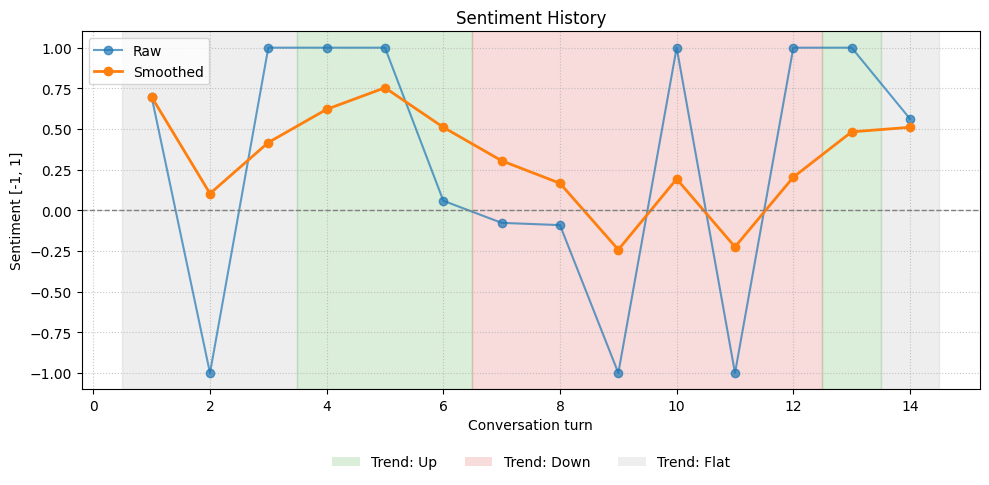

In [ ]:
# Plot the sentiment tracker history
def plot_sentiment_history(tracker, include_bots=False, title="Sentiment History"):
    xs, s_raw, s_ema, trends = [], [], [], []
    for i, t in enumerate(tracker.history, 1):
        if not include_bots and t.who.lower() != "human":
            continue
        xs.append(i)
        s_raw.append(t.s_raw)
        s_ema.append(t.s_ema)
        trends.append(t.trend)

    if not xs:
        print("No data to plot.")
        return

    plt.figure(figsize=(10, 5))

    # Merge consecutive same-trend regions
    start = xs[0]
    current_trend = trends[0]
    for i in range(1, len(xs) + 1):
        if i == len(xs) or trends[i] != current_trend:
            end = xs[i - 1]
            color = (
                '#6dbf6d' if current_trend == 'up'
                else '#e57373' if current_trend == 'down'
                else '#bfbfbf'
            )
            plt.axvspan(start - 0.5, end + 0.5, color=color, alpha=0.25)
            if i < len(xs):
                start = xs[i]
                current_trend = trends[i]

    # Plot sentiment lines
    plt.plot(xs, s_raw, marker='o', label="Raw", alpha=0.7, color='#1f77b4')
    plt.plot(xs, s_ema, marker='o', label="Smoothed", linewidth=2, color='#ff7f0e')
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)

    # Create custom legend patches for trend colors
    trend_patches = [
        Patch(facecolor='#6dbf6d', alpha=0.25, label='Trend: Up'),
        Patch(facecolor='#e57373', alpha=0.25, label='Trend: Down'),
        Patch(facecolor='#bfbfbf', alpha=0.25, label='Trend: Flat'),
    ]

    # Layout and axis styling
    plt.title(title)
    plt.xlabel("Conversation turn")
    plt.ylabel("Sentiment [-1, 1]")
    plt.ylim(-1.1, 1.1)
    plt.grid(True, linestyle=":", alpha=0.7)

    # Place both legends
    line_legend = plt.legend(loc='upper left')
    plt.gca().add_artist(line_legend)  # keep both legends
    plt.legend(handles=trend_patches, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)

    plt.tight_layout()
    plt.show()

plot_sentiment_history(tracker)

In [ ]:
from google.colab import files
import pandas as pd
import os

# Upload your file
uploaded = files.upload()

# Get the uploaded file name
filename = list(uploaded.keys())[0]
print(f"Uploaded: {filename}")


Saving test_dataset.json to test_dataset.json
Uploaded: test_dataset.json


In [ ]:
# ----------------------------
#   CONFIGURE COLUMN NAMES
# ----------------------------
LABEL_COL = "sentiment"      # e.g. "sentiment"
TEXT_COL = "text"            # e.g. "text" or "review"

# Output files
OUT_POS = "data_positive.jsonl"
OUT_NEG = "data_negative.jsonl"
OUT_NEU = "data_neutral.jsonl"


# ----------------------------
#   LOAD DATA (JSON or JSONL)
# ----------------------------
ext = os.path.splitext(filename)[1].lower()

if ext in [".jsonl", ".json"]:
    # Try loading as JSONL first
    try:
        df = pd.read_json(filename, lines=True)
        print("Loaded as JSONL (one JSON object per line).")
    except ValueError:
        df = pd.read_json(filename)
        print("Loaded as JSON array.")
else:
    raise ValueError("Unsupported file format. Please upload JSON or JSONL.")

print(f"Total rows loaded: {len(df)}")


# ----------------------------
#   SPLIT BY LABEL
# ----------------------------
df_pos = df[df[LABEL_COL] == "positive"]
df_neg = df[df[LABEL_COL] == "negative"]
df_neu = df[df[LABEL_COL] == "neutral"]

print("Counts:")
print("Positive:", len(df_pos))
print("Negative:", len(df_neg))
print("Neutral :", len(df_neu))


# ----------------------------
#   SAVE AS JSONL
# ----------------------------
df_pos.to_json(OUT_POS, orient="records", lines=True, force_ascii=False)
df_neg.to_json(OUT_NEG, orient="records", lines=True, force_ascii=False)
df_neu.to_json(OUT_NEU, orient="records", lines=True, force_ascii=False)

print("Files saved:")
print(OUT_POS)
print(OUT_NEG)
print(OUT_NEU)


Loaded as JSONL (one JSON object per line).
Total rows loaded: 14630
Counts:
Positive: 5524
Negative: 5602
Neutral : 3504
Files saved:
data_positive.jsonl
data_negative.jsonl
data_neutral.jsonl
